Mounted at /content/drive
Folders ready at: /content/drive/MyDrive/Oil_spill
Upload Sentinel-1 SAR image (preferably .tif)


Saving Oil_spill_spread.gif to Oil_spill_spread (1).gif
Image saved: /content/drive/MyDrive/Oil_spill/dataset/Oil_spill_spread (1).gif


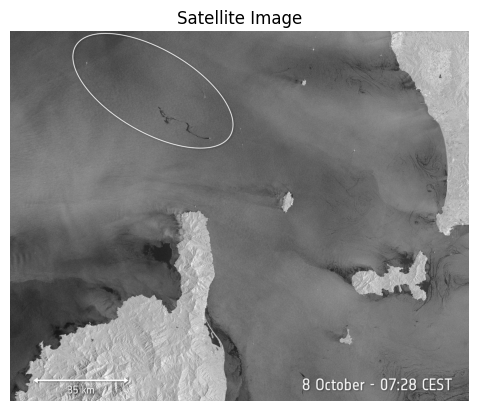

Detected spill candidates: 36


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Results saved: /content/drive/MyDrive/Oil_spill/results/spill_coordinates.csv


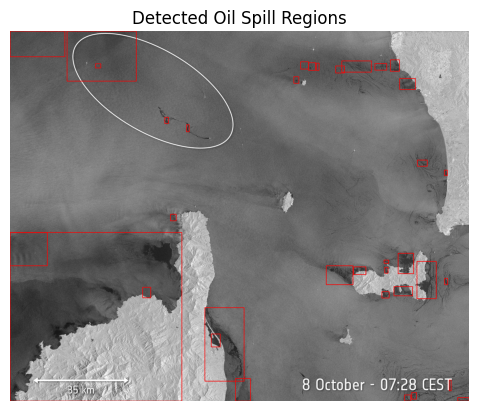

Map saved: /content/drive/MyDrive/Oil_spill/maps/spill_map.html
Pipeline completed


In [5]:
# ==========================================
# ADVANCED OIL SPILL DETECTION PIPELINE v2
# Sentinel-1 SAR → Spill Detection → Coordinates
# ==========================================

!pip install rasterio folium opencv-python pandas numpy matplotlib

# ==========================================
# 1. Imports
# ==========================================

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
import folium

from google.colab import drive
from google.colab import files

# ==========================================
# 2. Mount Drive and Setup Paths
# ==========================================

try:
    drive.mount('/content/drive', force_remount=True)
    BASE = "/content/drive/MyDrive/Oil_spill"
except:
    print("Drive not mounted, using local session storage.")
    BASE = "/content/oil_spill_results"

folders = ["dataset","masks","results","maps"]

for f in folders:
    os.makedirs(f"{BASE}/{f}", exist_ok=True)

print(f"Folders ready at: {BASE}")

# ==========================================
# 3. Upload Satellite Image
# ==========================================

print("Upload Sentinel-1 SAR image (preferably .tif)")

uploaded = files.upload()

if not uploaded:
    raise ValueError("No file uploaded. Please upload a SAR image to proceed.")

for name in uploaded.keys():
    img_path = f"{BASE}/dataset/{name}"
    os.makedirs(os.path.dirname(img_path), exist_ok=True)
    with open(img_path, "wb") as f:
        f.write(uploaded[name])

print("Image saved:", img_path)

# ==========================================
# 4. Load Image
# ==========================================

def load_image(path):
    img = cv2.imread(path)
    if img is None:
        # Fallback for formats cv2 might struggle with directly
        with rasterio.open(path) as src:
            img = src.read([1, 2, 3]).transpose(1, 2, 0)
    else:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

image = load_image(img_path)

plt.imshow(image)
plt.title("Satellite Image")
plt.axis("off")
plt.show()

# ==========================================
# 5. SAR Preprocessing
# ==========================================

gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
filtered = cv2.medianBlur(gray, 5)

# ==========================================
# 6. Dark Spot Detection
# ==========================================

threshold_value = np.mean(filtered) * 0.7
_, mask = cv2.threshold(filtered, threshold_value, 255, cv2.THRESH_BINARY_INV)
mask = cv2.medianBlur(mask, 5)

mask_path = f"{BASE}/masks/spill_mask.png"
cv2.imwrite(mask_path, mask)

# ==========================================
# 7. Morphological Filtering
# ==========================================

kernel = np.ones((5,5), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

# ==========================================
# 8. Contour Detection
# ==========================================

contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
detections = []

for c in contours:
    area = cv2.contourArea(c)
    if area < 200: continue
    x, y, w, h = cv2.boundingRect(c)
    detections.append([x, y, w, h, area])

print("Detected spill candidates:", len(detections))

# ==========================================
# 9. Pixel → Geo Coordinates
# ==========================================

coordinates = []
try:
    with rasterio.open(img_path) as dataset:
        for d in detections:
            x, y, w, h, area = d
            lon, lat = dataset.xy(y, x)
            coordinates.append([lat, lon, area])
except:
    print("Image is not GeoTIFF — coordinates unavailable")

# ==========================================
# 10. Spill Area Calculation
# ==========================================

pixel_size_m = 10
pixel_area_m2 = pixel_size_m * pixel_size_m
areas_km2 = [(d[4] * pixel_area_m2) / 1e6 for d in detections]

# ==========================================
# 11. Save Results
# ==========================================

df = pd.DataFrame({
    "latitude": [c[0] for c in coordinates] if coordinates else [None]*len(detections),
    "longitude": [c[1] for c in coordinates] if coordinates else [None]*len(detections),
    "area_km2": areas_km2
})

csv_path = f"{BASE}/results/spill_coordinates.csv"
df.to_csv(csv_path, index=False)
print("Results saved:", csv_path)

# ==========================================
# 12. Visualization
# ==========================================

vis = image.copy()
for d in detections:
    x, y, w, h, _ = d
    cv2.rectangle(vis, (x, y), (x+w, y+h), (255, 0, 0), 2)

plt.imshow(vis)
plt.title("Detected Oil Spill Regions")
plt.axis("off")
plt.show()

# ==========================================
# 13. Interactive Map
# ==========================================

if len(coordinates) > 0:
    m = folium.Map(location=[coordinates[0][0], coordinates[0][1]], zoom_start=6)
    for i, c in enumerate(coordinates):
        folium.CircleMarker(
            location=[c[0], c[1]],
            radius=6,
            color="red",
            popup=f"Spill Area: {areas_km2[i]:.2f} km"
        ).add_to(m)
    map_path = f"{BASE}/maps/spill_map.html"
    m.save(map_path)
    print("Map saved:", map_path)

print("Pipeline completed")